# Misspecified Bayesian DRO experiment

The following experiment compares three different posteriors over two data-generating processes (DGPs) on the newsvendor problem.
The objective function is $G(x, \xi) = h \max (0, x - \xi) + b \max (0, \xi - x) + c x$ where $h = 3$, $b = 8$, $c = 0$.
The decision variable $5 \leq x \leq 50$ is continuous.
The customer demand $\xi$ has support $\Xi = \mathbb{R}^+$.


In each replication $j = 1,\ldots,K$, we are given $N+M$ data points $\xi_1^{(j)}, \ldots, \xi_N^{(j)}, \xi_{N+1}^{(j)}, \ldots, \xi_{N+M}^{(j)}$ where the first $N=20$ points are the training samples and the last $M=50$ points are the test sample.
For each $\epsilon$ and each replication $j$, we calculate the out-of-sample mean $\mu^{(j)}(\epsilon)$ and variance $v^{(j)}(\epsilon)$ of the objective function under the $M$ test points:
$$
    \mu^{(j)}(\epsilon) := \mathbb{E}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M}~\sum_{i=1}^{M}~{G(x^{(j)}(\epsilon), \xi_{i}^{(j)})} \\
    v^{(j)}(\epsilon) := \mathbb{V}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M-1}~\sum_{i=1}^{M}~{\left(G(x^{(j)}(\epsilon), \xi_{i}^{(j)}) - \mu^{(j)}(\epsilon)\right)^2}
$$
where $\mathbb{P}^\star$ is the true data-generating process (DGP), $K$ is the number of replications, and $x^{(j)}(\epsilon)$ is the solution given by the Bayesian DRO algorithm on replication $j = 1,\ldots,K$.
Over all replications, we then calculate $\hat{\mu}_M(\epsilon)$ and $\hat{v}_M(\epsilon)$, where
$\hat{\mu}_M(\epsilon)$ is the mean-of-the-means,
and $\hat{v}_M(\epsilon)$ is the mean-of-the-variances plus the variance-of-the-means.
$$
    \hat{\mu}_M(\epsilon) :=  \frac{1}{K}~\sum_{j=1}^{K}~{ \mu^{(j)}(\epsilon)}, \\
    \hat{v}_M(\epsilon) := \underbrace{\frac{1}{K}~\sum_{j=1}^{K}~{v^{(j)}(\epsilon)}}_{\text{mean-of-the-variances}} + \underbrace{\frac{1}{K-1}~\sum_{j=1}^{K}~{\left( \mu^{(j)}(\epsilon) - \hat{\mu}_M(\epsilon) \right)^2}}_{\text{variance-of-the-means}}.
$$
Note that setting $M=1$ recovers the out-of-sample mean and variance in the usual way.


## Implementation details

In the following notebook, we concatenate all the CSV files together, then group by $\epsilon$ and the posterior method (`bayes`, `wll`, `mmd`):
- For each epsilon, posterior, & DGP, we save a CSV file where each row corresponds to a single replication $k$. The CSV contains the solution, time taken in seconds, out-of-sample mean $\mu^{(j)}(\epsilon)$, and out-of-sample variance $v^{(j)}(\epsilon)$.
- Each CSV file has a unique ID which maps to the `experiment.json` file. All the parameters can be found in the `experiment.csv` file.





In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
experiment_dir = Path("/dcs/large/u1508153/misdro/newsvendor_1d")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")

# check the number of train/test observations is the same:
assert len(results_df["num_observations"].unique()) == 1
assert len(results_df["num_test_observations"].unique()) == 1
num_observations = results_df["num_observations"]
num_test_observations = results_df["num_test_observations"]
results_df

,replication,mean_cost,var_cost,solution,dgp_time,likelihood_time,posterior_time,solve_time,algorithm,contamination,dgp,epsilon,lengthscale,num_likelihood_samples,num_observations,num_posterior_samples,num_replications,num_test_observations,posterior
uuid,,,,,,,,,,,,,,,,,,,
d32f2e19-66cf-4d4a-a298-3d2858e84ecc,0,31.749618,790.163279,17.38,0.010312,0.008916,0.000221,473.379873,bayesian_dro,0.0,truncated_normal,0.001,-1.0,100,20,100,200,50,bayes
d32f2e19-66cf-4d4a-a298-3d2858e84ecc,1,32.009702,762.765219,15.92,0.002157,0.012188,0.000304,451.029485,bayesian_dro,0.0,truncated_normal,0.001,-1.0,100,20,100,200,50,bayes
d32f2e19-66cf-4d4a-a298-3d2858e84ecc,2,28.381129,543.958291,15.32,0.001453,0.012212,0.000224,447.445020,bayesian_dro,0.0,truncated_normal,0.001,-1.0,100,20,100,200,50,bayes
d32f2e19-66cf-4d4a-a298-3d2858e84ecc,3,30.452384,659.743212,15.20,0.001497,0.012414,0.000223,447.084806,bayesian_dro,0.0,truncated_normal,0.001,-1.0,100,20,100,200,50,bayes
d32f2e19-66cf-4d4a-a298-3d2858e84ecc,4,32.991385,224.899811,21.71,0.001395,0.012274,0.000230,510.455824,bayesian_dro,0.0,truncated_normal,0.001,-1.0,100,20,100,200,50,bayes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
aaf359f9-2da8-4da5-9b75-ad0e7e4cfba5,195,119.612638,1023.503374,50.00,0.000677,0.009742,37.573753,80.020051,bayesian_dro,0.2,contaminated_exp,3.000,-1.0,100,20,100,200,50,mmd
aaf359f9-2da8-4da5-9b75-ad0e7e4cfba5,196,127.189470,608.042652,50.00,0.000621,0.009065,35.346610,76.161582,bayesian_dro,0.2,contaminated_exp,3.000,-1.0,100,20,100,200,50,mmd
aaf359f9-2da8-4da5-9b75-ad0e7e4cfba5,197,115.586466,972.036920,50.00,0.000614,0.009244,35.295163,76.455796,bayesian_dro,0.2,contaminated_exp,3.000,-1.0,100,20,100,200,50,mmd


In [3]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "posterior"])
df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "solve_time": ["mean"],
})
df

mean_cost              \
                                                       mean         var   
algorithm    dgp              epsilon posterior                           
bayesian_dro contaminated_exp 0.001   bayes       63.542741  330.937458   
                                      mmd         46.179590   97.075924   
                                      wll         62.120195  306.461865   
                              0.002   bayes       64.318063  336.763605   
                                      mmd         46.449693   96.860238   
...                                                     ...         ...   
             truncated_normal 2.500   mmd        110.509128   25.770707   
                                      wll        103.296757  125.989845   
                              3.000   bayes      106.337972   92.916836   
                                      mmd        110.867028   18.703679   
                                      wll        105.800483   93.592659   

                                                    var_cost posterior_time  \
                                                        mean           mean   
algorithm    dgp              epsilon posterior                               
bayesian_dro contaminated_exp 0.001   bayes       969.473005       0.000214   
                                      mmd        1418.512036      67.780795   
                                      wll         988.711369       0.015420   
                              0.002   bayes       959.199675       0.000210   
                                      mmd        1390.737940      63.890991   
...                                                      ...            ...   
             truncated_normal 2.500   mmd         554.509852      73.506633   
                                      wll         551.601442       0.016462   
                              3.000   bayes       552.128826       0.000223   
                                      mmd         554.509852      73.016364   
                                      wll         552.618262       0.017522   

                                                 solve_time  
                                                       mean  
algorithm    dgp              epsilon posterior              
bayesian_dro contaminated_exp 0.001   bayes      484.699581  
                                      mmd        439.613756  
                                      wll        474.339157  
                              0.002   bayes      427.138401  
                                      mmd        374.626314  
...                                                     ...  
             truncated_normal 2.500   mmd        168.697666  
                                      wll        165.115855  
                              3.000   bayes      143.725352  
                                      mmd        153.365941  
                                      wll        140.911228  

[108 rows x 5 columns]

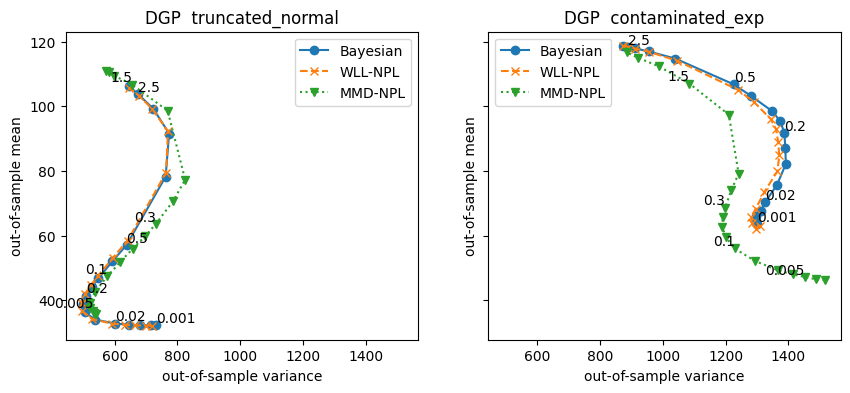

In [24]:
def plot_dgp(dgp: str, axis, algorithm: str = "bayesian_dro"):
    # get a dataframe for each posterior
    bayes_df = df.loc[algorithm, dgp, :, "bayes"]
    wll_df = df.loc[algorithm, dgp, :, "wll"]
    mmd_df = df.loc[algorithm, dgp, :, "mmd"]

    # mean of variances + variance of means
    bayes_bootstrap_var = bayes_df["var_cost"]["mean"] + bayes_df["mean_cost"]["var"]
    wll_bootstrap_var = wll_df["var_cost"]["mean"] + wll_df["mean_cost"]["var"]
    mmd_bootstrap_var = mmd_df["var_cost"]["mean"] + mmd_df["mean_cost"]["var"]

    # plot mean-variance trade-off
    axis.plot(bayes_bootstrap_var, bayes_df["mean_cost"]["mean"], marker='o', linestyle="solid", label="Bayesian")
    axis.plot(wll_bootstrap_var, wll_df["mean_cost"]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_bootstrap_var, mmd_df["mean_cost"]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    for i, epsilon in enumerate(mmd_df.index.get_level_values("epsilon")):
        if i % 4 == 0:
            axis.text(bayes_bootstrap_var[epsilon], bayes_df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        if (i+2) % 4 == 0:
            axis.text(mmd_bootstrap_var[epsilon], mmd_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10,4))
plot_dgp("truncated_normal", ax1)
plot_dgp("contaminated_exp", ax2)

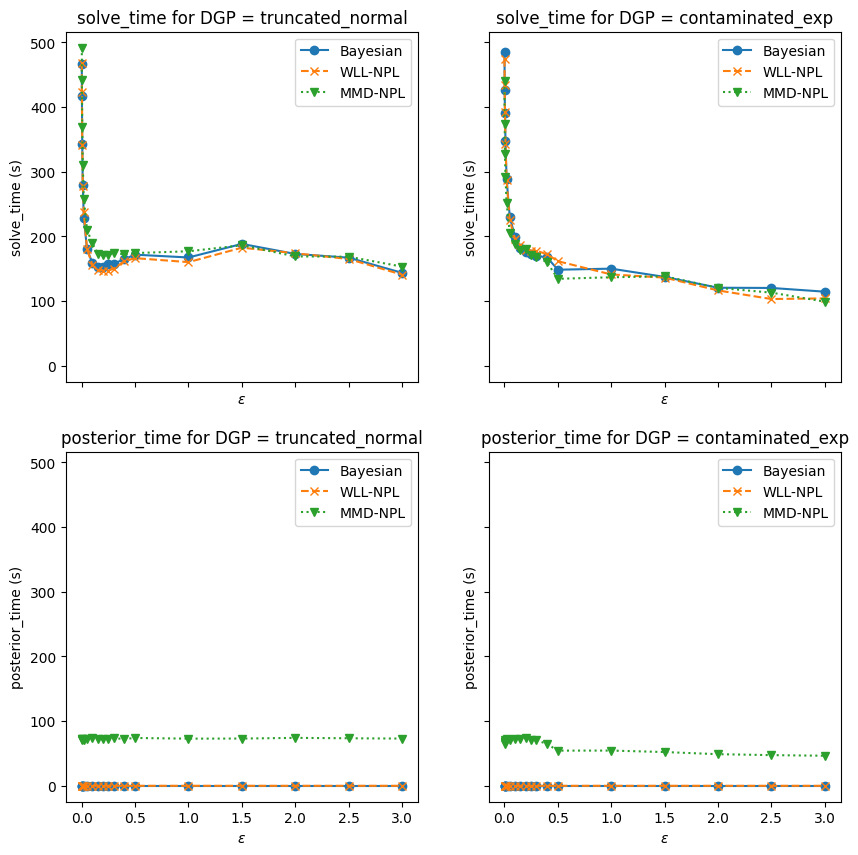

In [25]:
def plot_time_taken(dgp, time_name, axis, algorithm: str = "bayesian_dro"):
    # get a dataframe for each posterior
    bayes_df = df.loc[algorithm, dgp, :, "bayes"]
    wll_df = df.loc[algorithm, dgp, :, "wll"]
    mmd_df = df.loc[algorithm, dgp, :, "mmd"]
    
    axis.plot(bayes_df.index, bayes_df[time_name]["mean"], marker='o', linestyle="solid", label="Bayesian")
    axis.plot(wll_df.index, wll_df[time_name]["mean"], marker="x", linestyle="dashed", label="WLL-NPL")
    axis.plot(mmd_df.index, mmd_df[time_name]["mean"], marker="v", linestyle="dotted", label="MMD-NPL")
    axis.set_title(f"{time_name} for DGP = {dgp}")
    axis.legend()
    axis.set_xlabel("$\epsilon$")
    axis.set_ylabel(f"{time_name} (s)")


fig, (row1, row2) = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(10,10))
plot_time_taken("truncated_normal", "solve_time", row1[0])
plot_time_taken("contaminated_exp", "solve_time", row1[1])
plot_time_taken("truncated_normal", "posterior_time", row2[0])
plot_time_taken("contaminated_exp", "posterior_time", row2[1])